# Session 9: Synthetic Data Generation and RAG Evaluation with LangSmith

In the following notebook we'll explore a use-case for RAGAS' synthetic testset generation workflow, and use it to evaluate and iterate on a RAG pipeline with LangSmith!

**Learning Objectives:**
- Understand Ragas' knowledge graph-based synthetic data generation workflow
- Generate synthetic test sets with different query synthesizer types
- Load synthetic data into LangSmith for evaluation
- Evaluate a RAG chain using LangSmith evaluators
- Iterate on RAG pipeline parameters and measure the impact

## Table of Contents:

- **Breakout Room #1:** Synthetic Data Generation with Ragas
  - Task 1: Dependencies and API Keys
  - Task 2: Data Preparation and Knowledge Graph Construction
  - Task 3: Generating Synthetic Test Data
  - Question #1 & Question #2
  - 🏗️ Activity #1: Custom Query Distribution

- **Breakout Room #2:** RAG Evaluation with LangSmith
  - Task 4: LangSmith Dataset Setup
  - Task 5: Building a Basic RAG Chain
  - Task 6: Evaluating with LangSmith
  - Task 7: Modifying the Pipeline and Re-Evaluating
  - Question #3 & Question #4
  - 🏗️ Activity #2: Analyze Evaluation Results

---
# 🤝 Breakout Room #1
## Synthetic Data Generation with Ragas

## Task 1: Dependencies and API Keys

We'll need to install a number of API keys and dependencies, since we'll be leveraging a number of great technologies for this pipeline!

1. OpenAI's endpoints to handle the Synthetic Data Generation
2. OpenAI's Endpoints for our RAG pipeline and LangSmith evaluation
3. QDrant as our vectorstore
4. LangSmith for our evaluation coordinator!

Let's install and provide all the required information below!

## Dependencies and API Keys:

### NLTK Import

To prevent errors that may occur based on OS - we'll import NLTK and download the needed packages to ensure correct handling of data.

In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /home/luka/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/luka/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [2]:
import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

We'll also want to set a project name to make things easier for ourselves.

In [3]:
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - {uuid4().hex[0:8]}"

OpenAI's API Key!

In [4]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data using two complementary guides — a Health & Wellness Guide covering exercise, nutrition, sleep, and stress management, and a Mental Health & Psychology Handbook covering mental health conditions, therapeutic approaches, resilience, and daily mental health practices. The topical overlap between documents helps RAGAS build rich cross-document relationships in the knowledge graph.

Next, let's load our data into a familiar LangChain format using the `TextLoader`.

In [5]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader

loader = DirectoryLoader("data/", glob="*.txt", loader_cls=TextLoader)
docs = loader.load()
print(f"Loaded {len(docs)} documents: {[d.metadata['source'] for d in docs]}")

Loaded 2 documents: ['data/HealthWellnessGuide.txt', 'data/MentalHealthGuide.txt']


### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Unrolled SDG

In [6]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

/mnt/data/osobno/AIE9/09_Synthetic_Data_Generation_and_LangSmith/.venv/lib/python3.13/site-packages/pysbd/segmenter.py:66: SyntaxWarning: invalid escape sequence '\s'
  for match in re.finditer('{0}\s*'.format(re.escape(sent)), self.original_text):
/mnt/data/osobno/AIE9/09_Synthetic_Data_Generation_and_LangSmith/.venv/lib/python3.13/site-packages/pysbd/lang/arabic.py:29: SyntaxWarning: invalid escape sequence '\.'
  txt = re.sub('(?<={0})\.'.format(am), '∯', txt)
/mnt/data/osobno/AIE9/09_Synthetic_Data_Generation_and_LangSmith/.venv/lib/python3.13/site-packages/pysbd/lang/persian.py:29: SyntaxWarning: invalid escape sequence '\.'
  txt = re.sub('(?<={0})\.'.format(am), '∯', txt)


Next, we're going to instantiate our Knowledge Graph.

This graph will contain N number of nodes that have M number of relationships. These nodes and relationships (AKA "edges") will define our knowledge graph and be used later to construct relevant questions and responses.

In [7]:
from ragas.testset.graph import KnowledgeGraph

kg = KnowledgeGraph()
kg

KnowledgeGraph(nodes: 0, relationships: 0)

The first step we're going to take is to simply insert each of our full documents into the graph. This will provide a base that we can apply transformations to.

In [8]:
from ragas.testset.graph import Node, NodeType

for doc in docs:
    kg.nodes.append(
        Node(
            type=NodeType.DOCUMENT,
            properties={"page_content": doc.page_content, "document_metadata": doc.metadata}
        )
    )
kg

KnowledgeGraph(nodes: 2, relationships: 0)

Now, we'll apply the *default* transformations to our knowledge graph. This will take the nodes currently on the graph and transform them based on a set of [default transformations](https://docs.ragas.io/en/latest/references/transforms/#ragas.testset.transforms.default_transforms).

These default transformations are dependent on the corpus length, in our case:

- Producing Summaries -> produces summaries of the documents
- Extracting Headlines -> finding the overall headline for the document
- Theme Extractor -> extracts broad themes about the documents

It then uses cosine-similarity and heuristics between the embeddings of the above transformations to construct relationships between the nodes.

In [9]:
from ragas.testset.transforms import default_transforms, apply_transforms

transformer_llm = generator_llm
embedding_model = generator_embeddings

default_transforms = default_transforms(documents=docs, llm=transformer_llm, embedding_model=embedding_model)
apply_transforms(kg, default_transforms)
kg

Applying HeadlinesExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/2 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/8 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/18 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

KnowledgeGraph(nodes: 10, relationships: 21)

We can save and load our knowledge graphs as follows.

In [10]:
kg.save("usecase_data_kg.json")
usecase_data_kg = KnowledgeGraph.load("usecase_data_kg.json")
usecase_data_kg

KnowledgeGraph(nodes: 10, relationships: 21)

Using our knowledge graph, we can construct a "test set generator" - which will allow us to create queries.

In [11]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=embedding_model, knowledge_graph=usecase_data_kg)

However, we'd like to be able to define the kinds of queries we're generating - which is made simple by Ragas having pre-created a number of different "QuerySynthesizer"s.

Each of these Synthetsizers is going to tackle a separate kind of query which will be generated from a scenario and a persona.

In essence, Ragas will use an LLM to generate a persona of someone who would interact with the data - and then use a scenario to construct a question from that data and persona.

In [12]:
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer

query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.5),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]

## ❓ Question #1:

What are the three types of query synthesizers doing? Describe each one in simple terms.

##### Answer:
*Your answer here*

Finally, we can use our `TestSetGenerator` to generate our testset!

In [14]:
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,Whaat are the diffrent types of fats and why a...,[The Personal Wellness Guide A Comprehensive R...,Fats are necessary for hormone production and ...,single_hop_specifc_query_synthesizer
1,What is CBT-I used for?,[PART 3: SLEEP AND RECOVERY Chapter 7: The Sci...,Cognitive Behavioral Therapy for Insomnia (CBT...,single_hop_specifc_query_synthesizer
2,What is Chapter 16 about in the context of bui...,[PART 5: BUILDING HEALTHY HABITS Chapter 13: T...,Chapter 16 discusses managing headaches natura...,single_hop_specifc_query_synthesizer
3,World Health Organization what do they do abou...,[The Mental Health and Psychology Handbook A P...,"According to the context, the World Health Org...",single_hop_specifc_query_synthesizer
4,How does Dialectical Behavior Therapy (DBT) in...,[PART 2: THERAPEUTIC APPROACHES Chapter 4: Cog...,Dialectical Behavior Therapy (DBT) was origina...,single_hop_specifc_query_synthesizer
5,How can avoiding caffeine before bed help with...,[<1-hop>\n\nhour before bed - No caffeine afte...,Avoiding caffeine after 2 PM can improve sleep...,multi_hop_abstract_query_synthesizer
6,How does stress impact physical and mental hea...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,Stress is a body's response to demands or thre...,multi_hop_abstract_query_synthesizer
7,how sleep problems like insomnia relate to men...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,"The provided context explains that insomnia, w...",multi_hop_abstract_query_synthesizer
8,How can understanding the habit formation proc...,[<1-hop>\n\nPART 5: BUILDING HEALTHY HABITS Ch...,Understanding the habit formation process outl...,multi_hop_specific_query_synthesizer
9,How does the mental health handbook explain th...,[<1-hop>\n\nThe Mental Health and Psychology H...,The mental health handbook describes a strong ...,multi_hop_specific_query_synthesizer


### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [15]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/2 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/7 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/16 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [16]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,What role do micronutrients play in a balanced...,[PART 2: NUTRITION AND DIET Chapter 4: Fundame...,Micronutrients are inorganic elements like cal...,single_hop_specifc_query_synthesizer
1,How can Mornng Routines help improve your well...,[13: The Science of Habit Formation Habits are...,A intentional morning routine can boost produc...,single_hop_specifc_query_synthesizer
2,How does the shoulder contribute to overall ph...,[The Personal Wellness Guide A Comprehensive R...,The context discusses shoulder tension caused ...,single_hop_specifc_query_synthesizer
3,What is the psychology handbook about and why ...,[The Mental Health and Psychology Handbook A P...,The Mental Health and Psychology Handbook A Pr...,single_hop_specifc_query_synthesizer
4,How does stress impact physical and mental hea...,[<1-hop>\n\nPART 2: NUTRITION AND DIET Chapter...,Stress can negatively affect both physical hea...,multi_hop_abstract_query_synthesizer
5,"How can mindfulness and meditation, as part of...",[<1-hop>\n\nPART 2: NUTRITION AND DIET Chapter...,The context explains that mindfulness and medi...,multi_hop_abstract_query_synthesizer
6,How do macronutrients influence mental health ...,[<1-hop>\n\nPART 2: NUTRITION AND DIET Chapter...,The context explains that a balanced diet prov...,multi_hop_abstract_query_synthesizer
7,How do sleep cycles and stages relate to sleep...,[<1-hop>\n\nPART 2: NUTRITION AND DIET Chapter...,"Sleep occurs in cycles of about 90 minutes, al...",multi_hop_abstract_query_synthesizer
8,How do Chapters 4 and 16 together inform a hol...,[<1-hop>\n\nPART 2: NUTRITION AND DIET Chapter...,Chapter 4 emphasizes the importance of a balan...,multi_hop_specific_query_synthesizer
9,Considering the comprehensive guidance on exer...,[<1-hop>\n\nThe Personal Wellness Guide A Comp...,"In the first segment, it is explained that reg...",multi_hop_specific_query_synthesizer


## ❓ Question #2:

Ragas offers both an "unrolled" (manual) approach and an "abstracted" (automatic) approach to synthetic data generation. What are the trade-offs between these two approaches? When would you choose one over the other?

##### Answer:
*Your answer here*

---
## 🏗️ Activity #1: Custom Query Distribution

Modify the `query_distribution` to experiment with different ratios of query types.

### Requirements:
1. Create a custom query distribution with different weights than the default
2. Generate a new test set using your custom distribution
3. Compare the types of questions generated with the default distribution
4. Explain why you chose the weights you did

In [40]:
### YOUR CODE HERE ###

# Define a custom query distribution with different weights
# Generate a new test set and compare with the default
custom_query_distribution = [
    (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.7),
    (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.2),
    (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.1),
]
custom_testset = generator.generate(testset_size=10, query_distribution=custom_query_distribution)
custom_testset.to_pandas()

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,Proteins good for health?,[PART 2: NUTRITION AND DIET Chapter 4: Fundame...,Proteins are essential for muscle repair and i...,single_hop_specifc_query_synthesizer
1,What is habit formation and how can it help im...,[13: The Science of Habit Formation Habits are...,Habit formation involves behaviors becoming au...,single_hop_specifc_query_synthesizer
2,What is the significance of Tueday in the well...,[The Personal Wellness Guide A Comprehensive R...,Tuesday is part of the beginner weekly schedul...,single_hop_specifc_query_synthesizer
3,What is the psychology handbook about,[The Mental Health and Psychology Handbook A P...,The Mental Health and Psychology Handbook A Pr...,single_hop_specifc_query_synthesizer
4,What does PART 2 encompass in the context of t...,[PART 2: THERAPEUTIC APPROACHES Chapter 4: Cog...,PART 2 covers therapeutic approaches including...,single_hop_specifc_query_synthesizer
5,"How does serotonin influence mental health, an...",[Write letters to or from your future self Jou...,Exercise affects the brain in multiple benefic...,single_hop_specifc_query_synthesizer
6,What is the purpose of an appendix in the cont...,[social interactions How to set and maintain b...,"The appendix provides mental health resources,...",single_hop_specifc_query_synthesizer
7,How do the principles of balanced nutrition an...,[<1-hop>\n\nPART 2: NUTRITION AND DIET Chapter...,The 'Fundamentals of Healthy Eating' emphasize...,multi_hop_abstract_query_synthesizer
8,How does exercise for mental health relate to ...,[<1-hop>\n\nWrite letters to or from your futu...,Exercise affects the brain by increasing neuro...,multi_hop_abstract_query_synthesizer
9,how CBT and CBT-I help with mental health like...,[<1-hop>\n\nWrite letters to or from your futu...,"Based on the context, CBT (Cognitive Behaviora...",multi_hop_specific_query_synthesizer


We'll need to provide our LangSmith API key, and set tracing to "true".

---
# 🤝 Breakout Room #2
## RAG Evaluation with LangSmith

## Task 4: LangSmith Dataset

Now we can move on to creating a dataset for LangSmith!

First, we'll need to create a dataset on LangSmith using the `Client`!

We'll name our Dataset to make it easy to work with later.

In [17]:
from langsmith import Client
import uuid

client = Client()

dataset_name = f"Use Case Synthetic Data - AIE9 - {uuid.uuid4()}"

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Synthetic Data for Use Cases"
)

We'll iterate through the RAGAS created dataframe - and add each example to our created dataset!

> NOTE: We need to conform the outputs to the expected format - which in this case is: `question` and `answer`.

In [18]:
for data_row in dataset.to_pandas().iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["user_input"]
      },
      outputs={
          "answer": data_row[1]["reference"]
      },
      metadata={
          "context": data_row[1]["reference_contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

## Basic RAG Chain

Time for some RAG!


In [19]:
rag_documents = docs

To keep things simple, we'll just use LangChain's recursive character text splitter!


In [20]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

We'll create our vectorstore using OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) embedding model.

In [21]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

As usual, we will power our RAG application with Qdrant!

In [22]:
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="use_case_rag"
)

In [23]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

To get the "A" in RAG, we'll provide a prompt.

In [24]:
from langchain_core.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

As is usual: We'll be using `gpt-4.1-mini` for our RAG!

In [25]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

Finally, we can set-up our RAG LCEL chain!

In [26]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [27]:
rag_chain.invoke({"question" : "What are some recommended exercises for lower back pain?"})

'Recommended exercises for lower back pain include:\n\n- Cat-Cow Stretch: Start on hands and knees, alternate between arching your back up (cat) and letting it sag down (cow). Do 10-15 repetitions.\n- Bird Dog: From hands and knees, extend opposite arm and leg while keeping your core engaged. Hold for 5 seconds, then switch sides. Do 10 repetitions per side.\n- Partial Crunches: Lie on your back with knees bent, cross arms over chest, tighten stomach muscles and raise shoulders off floor. Hold briefly, then lower. Do 8-12 repetitions.\n- Knee-to-Chest Stretch: Lie on your back, pull one knee toward your chest while keeping the other foot flat. Hold for 15-30 seconds, then switch legs.\n- Pelvic Tilts: Lie on your back with knees bent, flatten your back against the floor by tightening abs and tilting pelvis up slightly. Hold for 10 seconds, repeat 8-12 times.'

## LangSmith Evaluation Set-up

We'll use OpenAI's GPT-4.1 as our evaluation LLM for our base Evaluators.

In [28]:
eval_llm = ChatOpenAI(model="gpt-4.1")

We'll be using a number of evaluators - from LangSmith provided evaluators, to a few custom evaluators!

In [29]:
from openevals.llm import create_llm_as_judge
from langsmith.evaluation import evaluate

# 1. QA Correctness (replaces LangChainStringEvaluator("qa"))
qa_evaluator = create_llm_as_judge(
    prompt="You are evaluating a QA system. Given the input, assess whether the prediction is correct.\n\nInput: {inputs}\nPrediction: {outputs}\nReference answer: {reference_outputs}\n\nIs the prediction correct? Return 1 if correct, 0 if incorrect.",
    feedback_key="qa",
    model="openai:gpt-4o" ,  # pass your LangChain chat model directly
)

# 2. Labeled Helpfulness (replaces LangChainStringEvaluator("labeled_criteria"))
labeled_helpfulness_evaluator = create_llm_as_judge(
    prompt=(
        "You are assessing a submission based on the following criterion:\n\n"
        "helpfulness: Is this submission helpful to the user, "
        "taking into account the correct reference answer?\n\n"
        "Input: {inputs}\n"
        "Submission: {outputs}\n"
        "Reference answer: {reference_outputs}\n\n"
        "Does the submission meet the criterion? Return 1 if yes, 0 if no."
    ),
    feedback_key="helpfulness",
    model="openai:gpt-4o" ,
)

# 3. Dopeness (replaces LangChainStringEvaluator("criteria"))
dopeness_evaluator = create_llm_as_judge(
    prompt=(
        "You are assessing a submission based on the following criterion:\n\n"
        "dopeness: Is this response dope, lit, cool, or is it just a generic response?\n\n"
        "Input: {inputs}\n"
        "Submission: {outputs}\n\n"
        "Does the submission meet the criterion? Return 1 if yes, 0 if no."
    ),
    feedback_key="dopeness",
    model="openai:gpt-4o" ,
)

> **Describe what each evaluator is evaluating:**
>
> - `qa_evaluator`:
> - `labeled_helpfulness_evaluator`:
> - `dopeness_evaluator`:

## LangSmith Evaluation

In [30]:
evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'slight-request-15' at:
https://smith.langchain.com/o/414a027d-cf2c-4cf3-a5e1-662995f75f0e/datasets/64c35695-1f3a-40f1-afc7-f617edbe7c39/compare?selectedSessions=3d5977aa-9e2e-418d-9a4c-51486e591ae4




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.qa,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,What are the key mental health resources avail...,The key mental health resources available to s...,None,The context highlights various mental health r...,True,True,False,4.251085,a546857d-ef89-4d58-a518-c0cd5d0dfaa1,019c6cc2-c1fe-79f0-bcea-afb16de3c82a
1,How can mental health resources support the im...,Mental health resources can support the import...,None,Mental health resources play a crucial role in...,True,True,True,3.480073,2f561acc-d5ac-42bf-a218-a44b5dd1e776,019c6cc3-0c29-74f3-a7f5-76ddfe60bf49
2,Considering the comprehensive guidance on exer...,Incorporating regular aerobic and strength tra...,None,"In the first segment, it is explained that reg...",True,True,True,3.477118,de9d0ffb-a7a0-4760-9173-c95601c783a2,019c6cc3-4bc5-75f2-8a5a-aa65574f5519
3,How do Chapters 4 and 16 together inform a hol...,I don't know.,None,Chapter 4 emphasizes the importance of a balan...,False,False,False,1.274074,a04e9f1e-5858-41a8-b830-f2584eadc58f,019c6cc3-a1c5-7870-b3ca-fade91db2c2e
4,How do sleep cycles and stages relate to sleep...,The provided context does not explicitly descr...,None,"Sleep occurs in cycles of about 90 minutes, al...",False,True,True,3.477244,305655a6-d5db-4791-a7b3-138a8fd0fa93,019c6cc3-dcf6-7041-85bc-52c770165607
5,How do macronutrients influence mental health ...,The provided context does not specifically exp...,None,The context explains that a balanced diet prov...,False,False,False,2.480761,9511deef-df66-4b4c-8b62-e382b1459cf3,019c6cc4-17c8-7cd3-826a-38d6f1de4b50
6,"How can mindfulness and meditation, as part of...","According to the context, mindfulness and medi...",None,The context explains that mindfulness and medi...,True,True,False,4.601448,28bbbb08-4263-4677-a14f-e0efe6dd92ec,019c6cc4-495f-74f0-bf7f-9b1137064e7a
7,How does stress impact physical and mental hea...,Stress impacts physical health by causing symp...,None,Stress can negatively affect both physical hea...,True,True,True,4.601612,9e121d52-721d-4d3f-8954-555b8b7ffd9c,019c6cc4-84f6-7420-99a8-c88663f71c5c
8,What is the psychology handbook about and why ...,The Mental Health and Psychology Handbook is a...,None,The Mental Health and Psychology Handbook A Pr...,True,True,False,2.456202,cf94f75b-d8c9-4bbf-a588-ea6bc2557eed,019c6cc4-c823-79b2-9039-aec53a3a2062
9,How does the shoulder contribute to overall ph...,I don't know.,None,The context discusses shoulder tension caused ...,False,False,False,1.050866,fc7ff949-7e4a-4ed0-83e2-ea86c34bd0e0,019c6cc5-0cf1-75b3-a20d-f412892f92a8


## Dope-ifying Our Application

We'll be making a few changes to our RAG chain to increase its performance on our SDG evaluation test dataset!

- Include a "dope" prompt augmentation
- Use larger chunks
- Improve the retriever model to: `text-embedding-3-large`

Let's see how this changes our evaluation!

In [31]:
DOPENESS_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Make your answer rad, ensure high levels of dopeness. Do not be generic, or give generic responses.

Context: {context}
Question: {question}
"""

dopeness_rag_prompt = ChatPromptTemplate.from_template(DOPENESS_RAG_PROMPT)

In [32]:
rag_documents = docs

In [33]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

## ❓ Question #3:

Why would modifying our chunk size modify the performance of our application?

##### Answer:
*Your answer here*

In [34]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

## ❓ Question #4:

Why would modifying our embedding model modify the performance of our application?

##### Answer:
*Your answer here*

In [35]:
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG Docs"
)

In [36]:
retriever = vectorstore.as_retriever()

Setting up our new and improved DOPE RAG CHAIN.

In [37]:
dopeness_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | dopeness_rag_prompt | llm | StrOutputParser()
)

Let's test it on the same output that we saw before.

In [38]:
dopeness_rag_chain.invoke({"question" : "How can I improve my sleep quality?"})

'Alright, let’s crank your sleep quality to legendary levels! Based on the rad wisdom packed in the sleep chronicles, here’s your ultimate playbook to conquer the nightly snooze game:\n\n1. **Lock in a consistent sleep schedule** — like a boss. Go to bed and rise at the same time every day, even on weekends. Your body’s internal clock will thank you with epic rest.\n\n2. **Bedtime rituals that slay:** Wind down with chill activities — think reading, gentle stretches, or a warm bath. This signals your brain it’s time to enter dreamland.\n\n3. **Perfect your sleep lair:** Keep your bedroom cold (65-68°F / 18-20°C), pitch-black (blackout curtains or a sleep mask), and quiet as a ninja (white noise machines or earplugs help!).\n\n4. **Dodge the screen glow** 1-2 hours before hitting the hay — those blue rays are a sleep-crushing villain.\n\n5. **Caffeine cutoff:** Avoid that energy juice after 2 PM unless you want your brain partying when it should be chilling.\n\n6. **Move it wisely:** Re

Finally, we can evaluate the new chain on the same test set!

In [39]:
evaluate(
    dopeness_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "dopeness_rag_chain"},
)

View the evaluation results for experiment: 'frosty-kitten-50' at:
https://smith.langchain.com/o/414a027d-cf2c-4cf3-a5e1-662995f75f0e/datasets/64c35695-1f3a-40f1-afc7-f617edbe7c39/compare?selectedSessions=04c90c10-7a4b-4fdd-b2bb-afbea3f3377e




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.qa,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,What are the key mental health resources avail...,"Alright, buckle up for a mental health power p...",None,The context highlights various mental health r...,True,True,True,4.686827,a546857d-ef89-4d58-a518-c0cd5d0dfaa1,019c6d30-d798-7e10-86a7-2762e4474420
1,How can mental health resources support the im...,"Alright, let’s crank up the mental health mojo...",None,Mental health resources play a crucial role in...,True,True,True,6.040292,2f561acc-d5ac-42bf-a218-a44b5dd1e776,019c6d31-4e4f-7f62-aeb9-f9675ae9e4b0
2,Considering the comprehensive guidance on exer...,"Alright, let's crank this up to max dopeness m...",None,"In the first segment, it is explained that reg...",True,True,True,5.836408,de9d0ffb-a7a0-4760-9173-c95601c783a2,019c6d31-acb7-7e72-92bc-02878d231393
3,How do Chapters 4 and 16 together inform a hol...,"Alright, let’s level up your mental wellness g...",None,Chapter 4 emphasizes the importance of a balan...,False,False,True,4.887406,a04e9f1e-5858-41a8-b830-f2584eadc58f,019c6d32-1c50-7032-883c-ac0965837e8a
4,How do sleep cycles and stages relate to sleep...,"Alright, let's ride the wave of sleep science ...",None,"Sleep occurs in cycles of about 90 minutes, al...",True,True,True,6.446199,305655a6-d5db-4791-a7b3-138a8fd0fa93,019c6d32-69ef-7043-b7ec-ae342aa9748f
5,How do macronutrients influence mental health ...,"Yo, let’s break down the mind-body hustle like...",None,The context explains that a balanced diet prov...,True,True,True,7.166926,9511deef-df66-4b4c-8b62-e382b1459cf3,019c6d32-acb9-7681-98e7-cfcfda13d551
6,"How can mindfulness and meditation, as part of...","Alright, here’s the ultra-dopeness on how mind...",None,The context explains that mindfulness and medi...,True,True,True,5.427196,28bbbb08-4263-4677-a14f-e0efe6dd92ec,019c6d33-24b8-7802-b579-657f52c18d36
7,How does stress impact physical and mental hea...,"Yo, stress is like that sneaky villain messing...",None,Stress can negatively affect both physical hea...,True,True,True,6.514188,9e121d52-721d-4d3f-8954-555b8b7ffd9c,019c6d33-7e4c-71a3-aaf2-a891cb83abc4
8,What is the psychology handbook about and why ...,"Alright, let’s dive deep into the epic essence...",None,The Mental Health and Psychology Handbook A Pr...,True,True,True,3.266289,cf94f75b-d8c9-4bbf-a588-ea6bc2557eed,019c6d33-d18f-7122-8809-329937c6855d
9,How does the shoulder contribute to overall ph...,"Alright, let's crank up the rad factor on this...",None,The context discusses shoulder tension caused ...,True,True,True,3.789114,fc7ff949-7e4a-4ed0-83e2-ea86c34bd0e0,019c6d34-2452-7143-b816-d9127c335619


---
## 🏗️ Activity #2: Analyze Evaluation Results

Provide a screenshot of the difference between the two chains in LangSmith, and explain why you believe certain metrics changed in certain ways.

##### Answer:
*Your answer here*

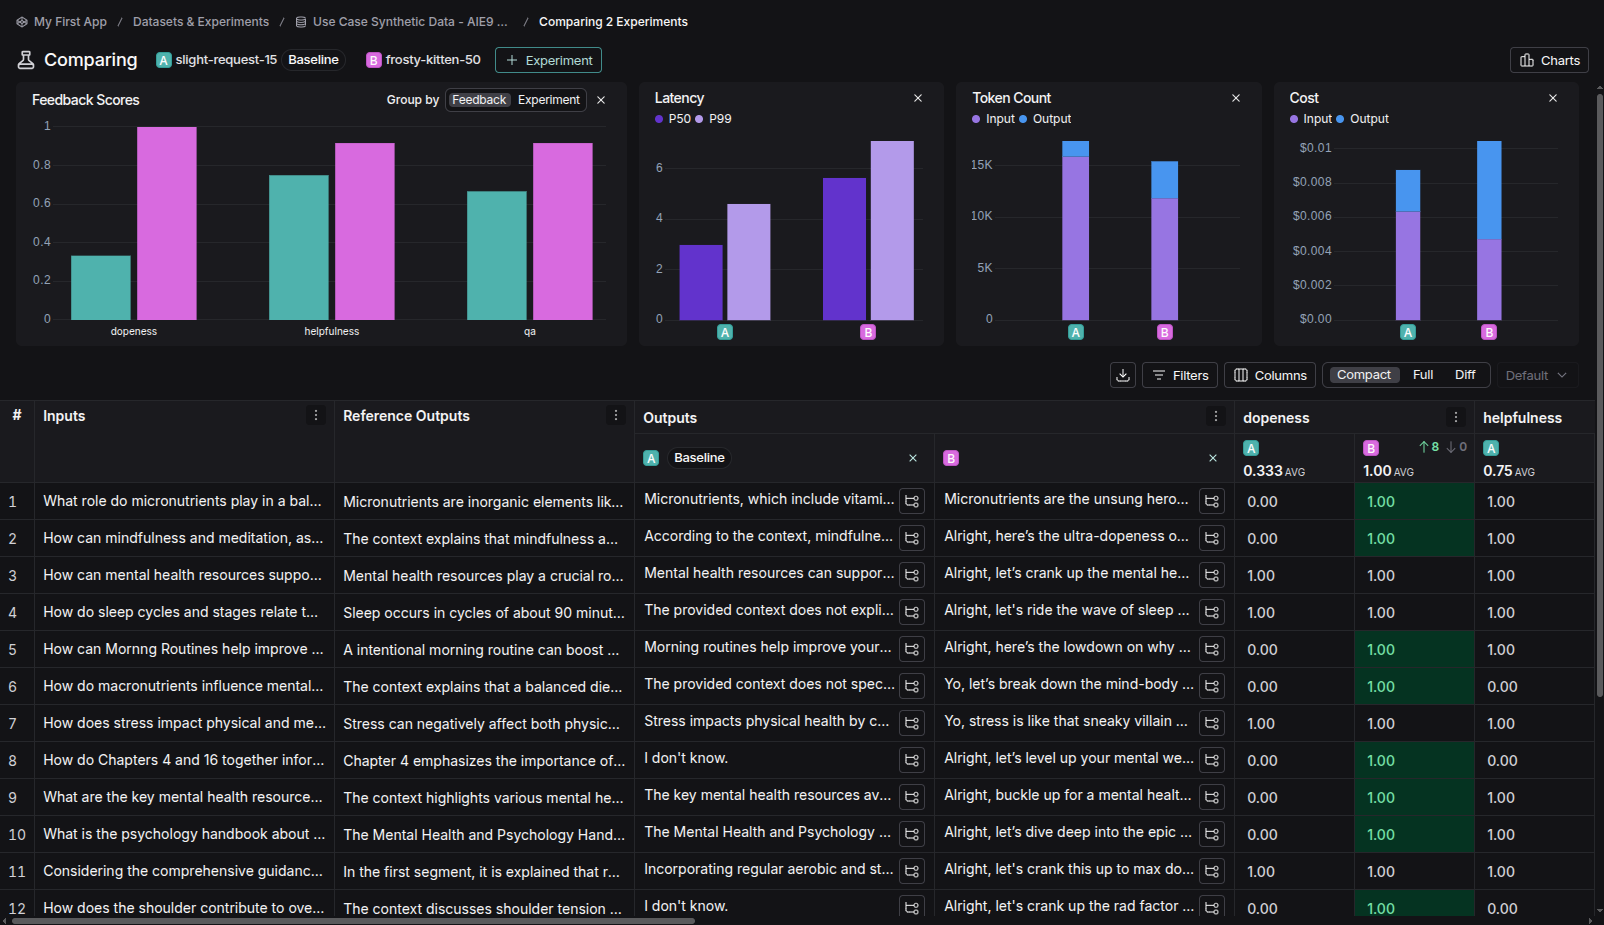

In [42]:
from IPython.display import Image

Image('images/image1.png')

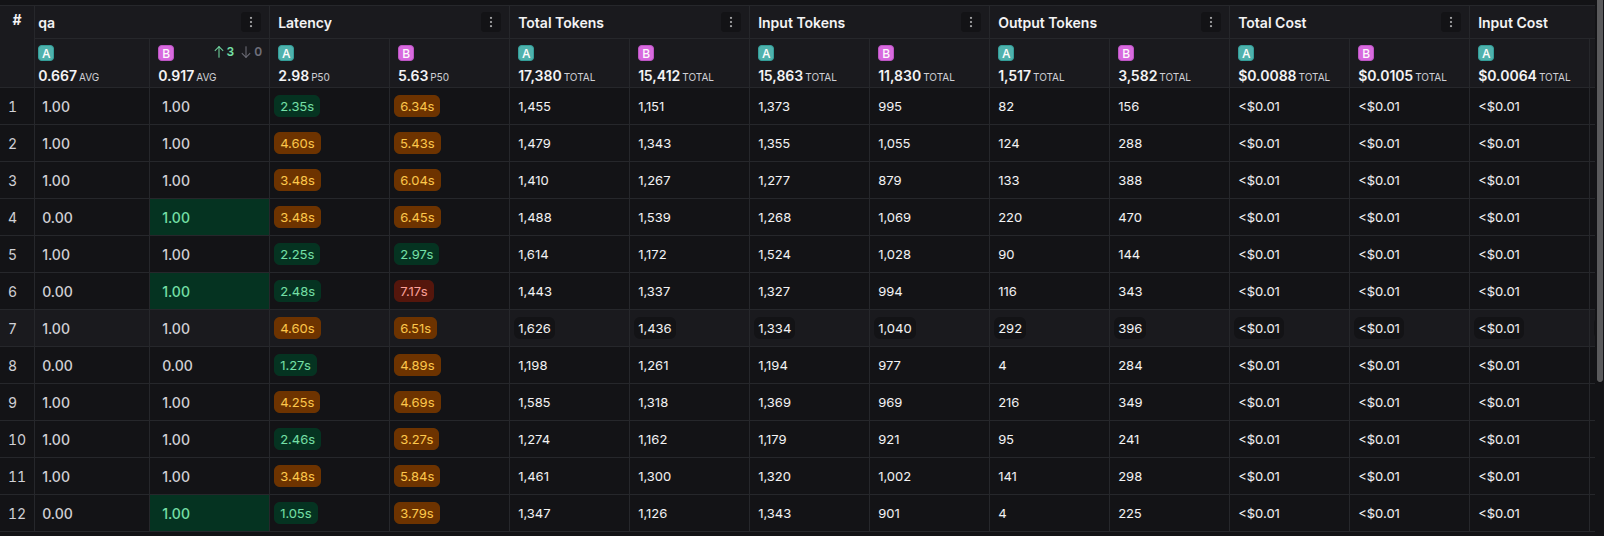

In [43]:
Image('images/image2.png')

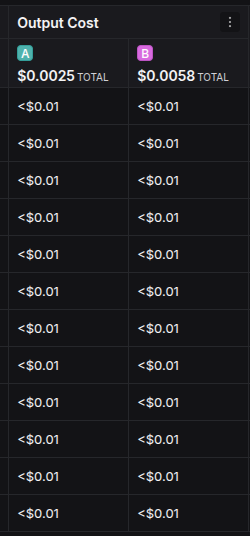

In [44]:
Image('images/image3.png')

---
## Summary

In this session, we:

1. **Generated synthetic test data** using Ragas' knowledge graph-based approach
2. **Explored query synthesizers** for creating diverse question types
3. **Loaded synthetic data** into a LangSmith dataset for evaluation
4. **Built and evaluated a RAG chain** using LangSmith evaluators
5. **Iterated on the pipeline** by modifying chunk size, embedding model, and prompt — then measured the impact

### Key Takeaways:

- **Synthetic data generation** is critical for early iteration — it provides high-quality signal without manually creating test data
- **LangSmith evaluators** enable systematic comparison of pipeline versions
- **Small changes matter** — chunk size, embedding model, and prompt modifications can significantly affect evaluation scores